# London: khám phá dữ liệu tội phạm và nguồn lực cảnh sát

Phạm vi 32 borough MPS. Notebook sử dụng dữ liệu đã xử lý bởi `run_pipeline.py`. Dân số cố định Census 2021; FTE Camden thiếu từ 08/2024. Không điền dữ liệu thiếu thành 0.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / "data/processed").exists():
    ROOT = ROOT.parent
assert (ROOT / "data/processed").exists(), "Mở notebook từ Do_An hoặc Do_An/notebooks"
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
monthly = pd.read_parquet(ROOT / "data/processed/monthly.parquet")
facts = pd.read_parquet(ROOT / "data/processed/crime_borough.parquet")
print("Borough-category-month rows:", len(facts))
print("Borough-month rows:", len(monthly))
display(monthly.head())

Borough-category-month rows: 74784
Borough-month rows: 2304


,borough_name,month,crime_count,borough_code,population_2021,rate_per_1000,rolling_12_count,rolling_12_rate,mom_pct,yoy_pct,outlier_iqr,is_hotspot,officer_fte,minutes,abstracted_minutes,officers_per_10000,abstraction_hours,abstraction_share_pct,abstraction_hours_per_fte
0,Barking and Dagenham,2020-08-01,1570,E09000002,218865,7.173372,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Barking and Dagenham,2020-09-01,1572,E09000002,218865,7.182510,NaN,NaN,0.127389,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Barking and Dagenham,2020-10-01,1637,E09000002,218865,7.479496,NaN,NaN,4.134860,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Barking and Dagenham,2020-11-01,1642,E09000002,218865,7.502342,NaN,NaN,0.305437,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Barking and Dagenham,2020-12-01,1430,E09000002,218865,6.533708,NaN,NaN,-12.911084,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Chất lượng và dữ liệu thiếu
Kiểm tra phạm vi thời gian, khóa trùng và FTE thiếu. Phân biệt thiếu trước 08/2021 với thiếu Camden sau 08/2024.

In [2]:
display(monthly.isna().sum().to_frame("missing"))
assert not monthly.duplicated(["borough_name", "month"]).any()
assert monthly.crime_count.sum() == facts.crime_count.sum()
display(monthly[(monthly.month >= "2021-08-01") & monthly.officer_fte.isna()][["borough_name", "month"]])

,missing
borough_name,0
month,0
crime_count,0
borough_code,0
population_2021,0
rate_per_1000,0
rolling_12_count,352
rolling_12_rate,352
mom_pct,32
yoy_pct,384


,borough_name,month
408,Camden,2024-08-01
409,Camden,2024-09-01
410,Camden,2024-10-01
411,Camden,2024-11-01
412,Camden,2024-12-01
413,Camden,2025-01-01
414,Camden,2025-02-01
415,Camden,2025-03-01
416,Camden,2025-04-01
417,Camden,2025-05-01


## Sinh sáu hình EDA
Hàm `run_eda` trong src/eda.py vẽ bằng Matplotlib/Seaborn và lưu PNG để đưa vào báo cáo. Mở file code để giải thích từng phép tổng hợp, trục và mẫu số.

Saved six EDA figures and findings to E:\truc_quan_hoa_du_lieu\Do_An\reports


01_monthly_trend.png


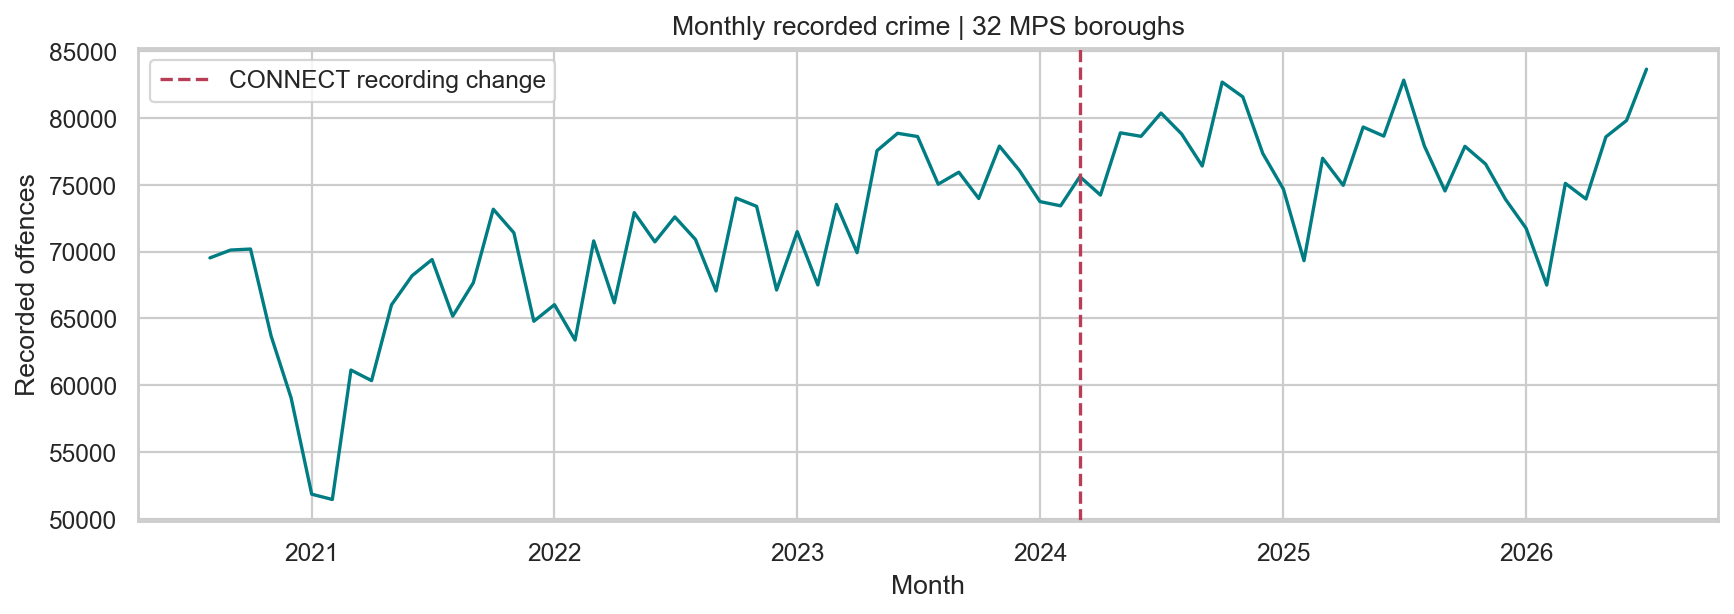

02_borough_ranking.png


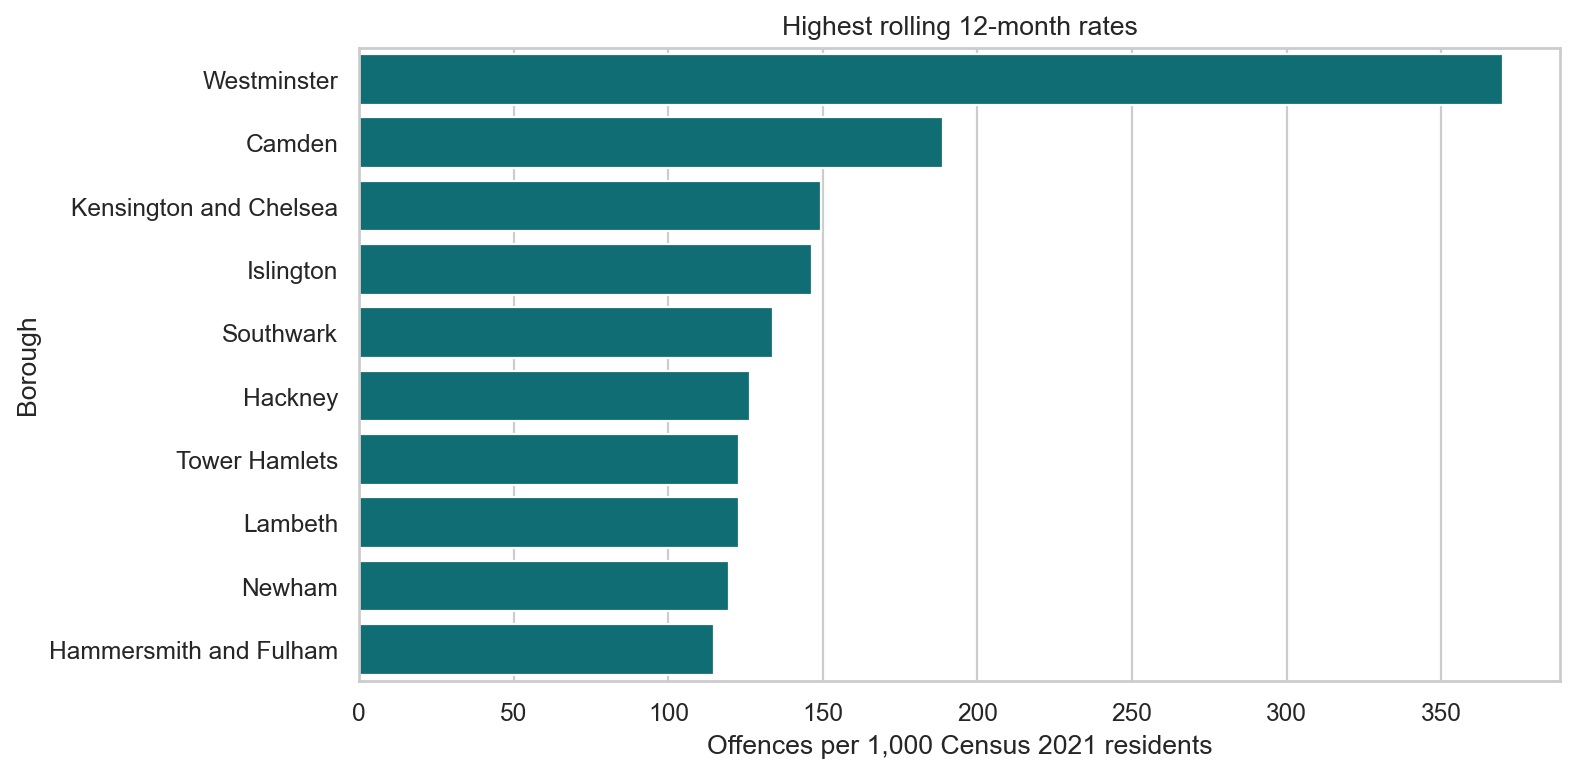

03_group_boxplot.png


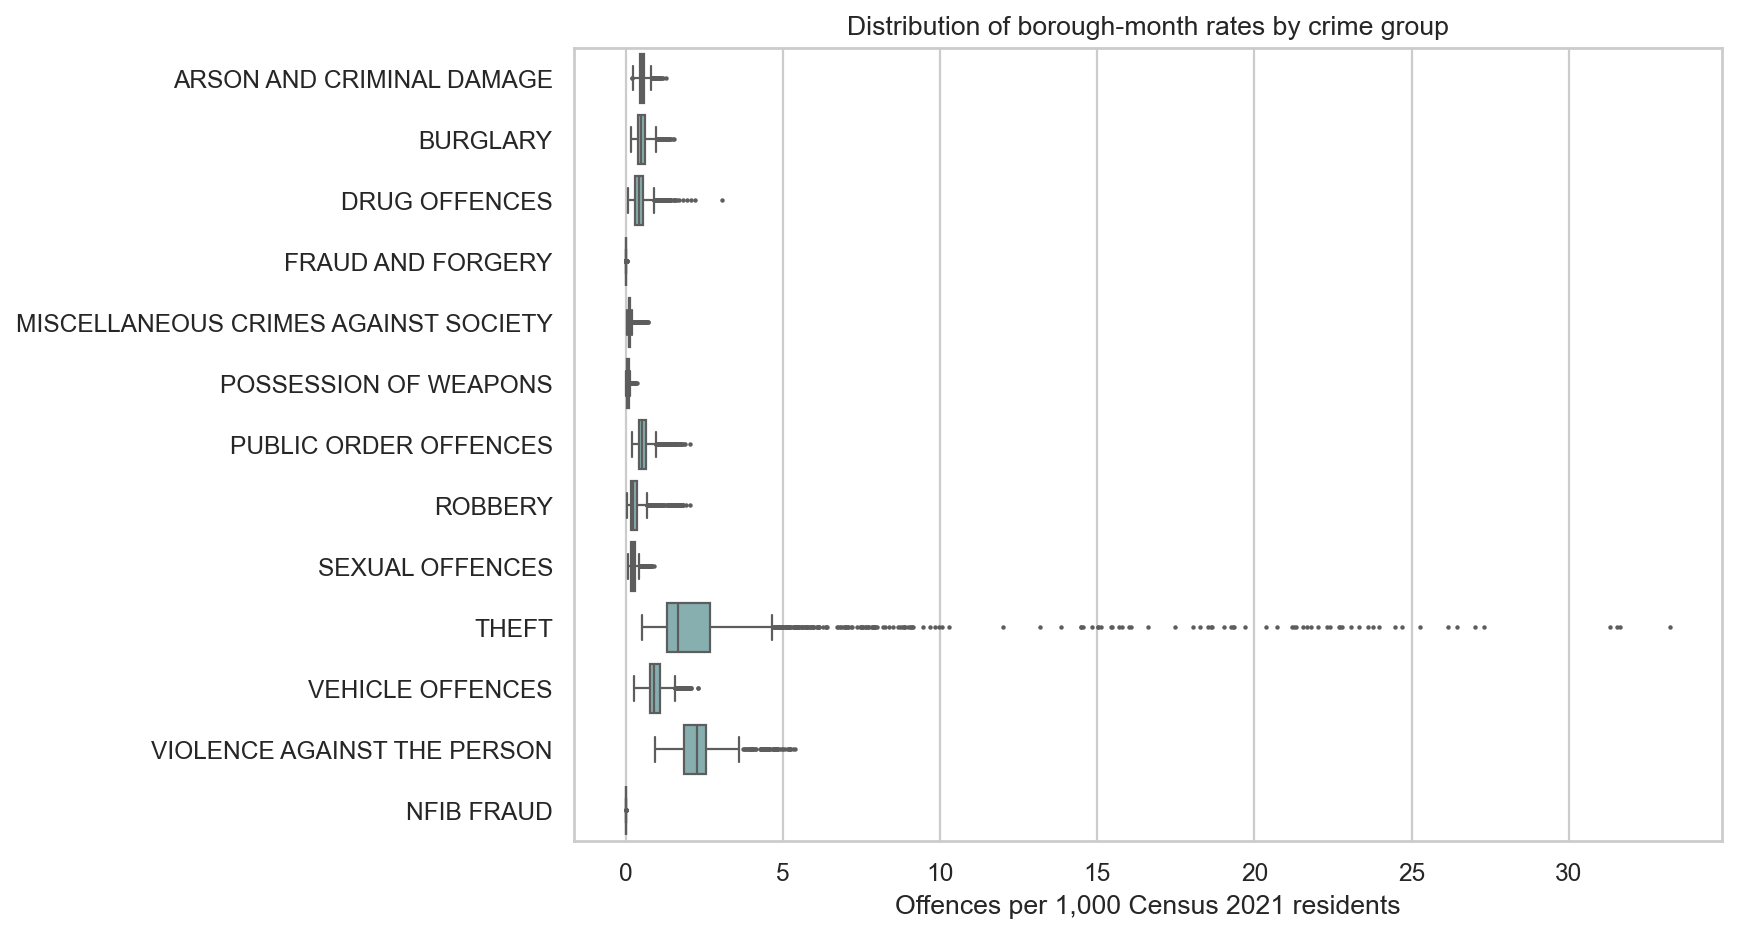

04_borough_group_heatmap.png


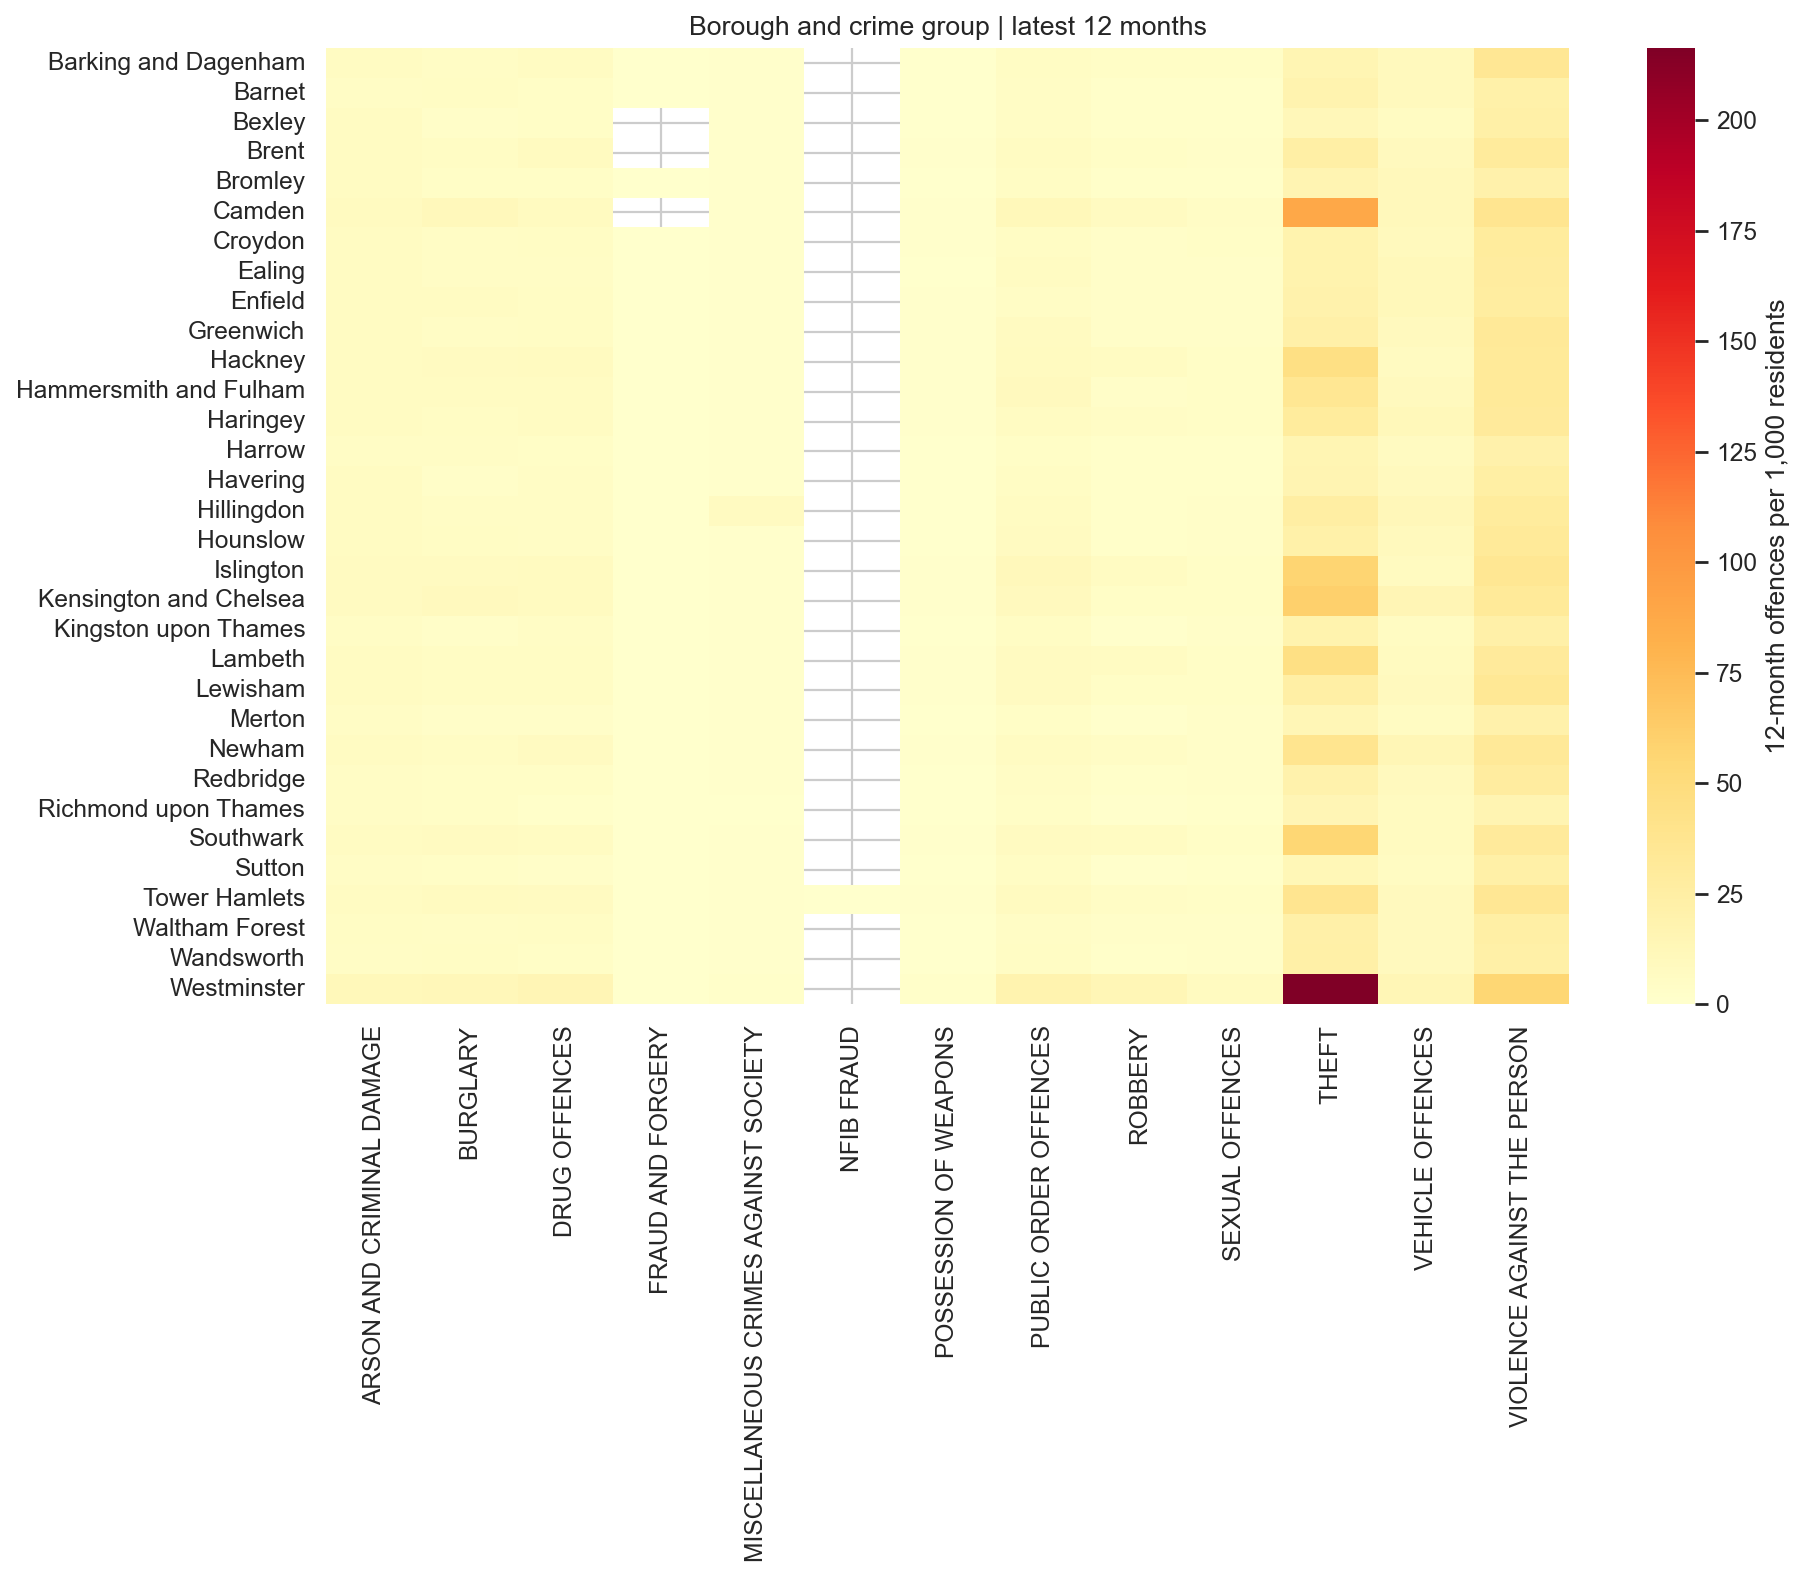

05_workforce_scatter.png


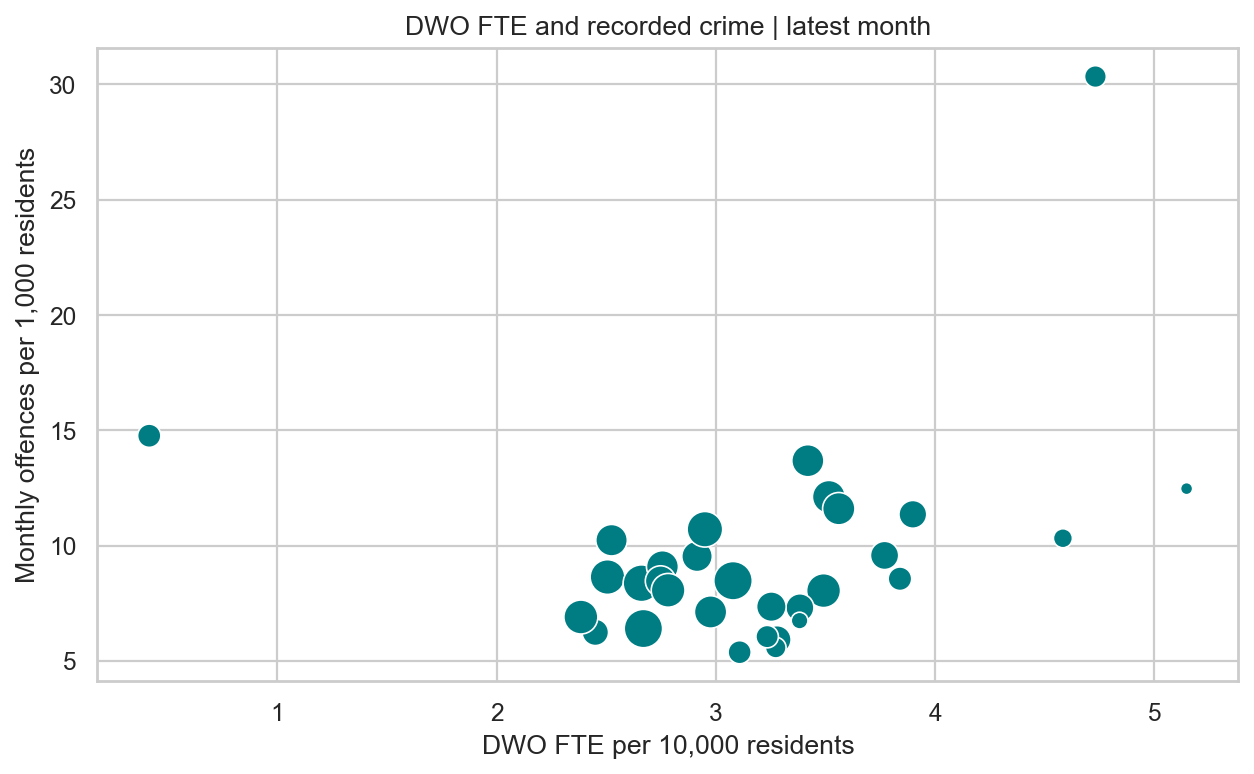

06_rate_histogram.png


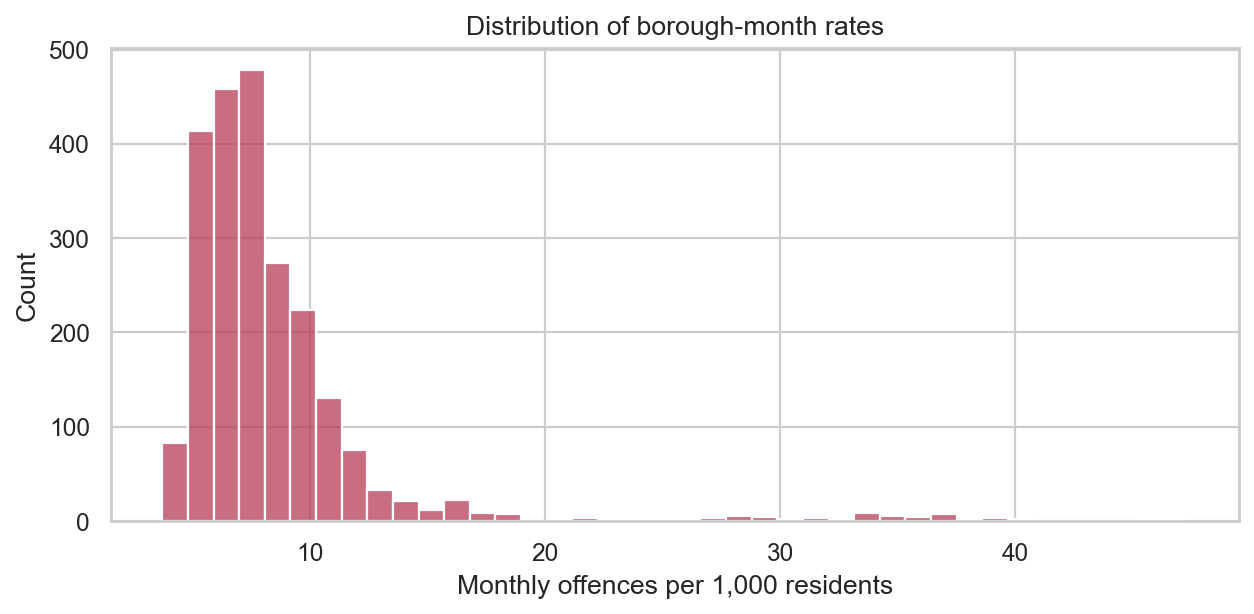

In [3]:
from eda import run_eda
run_eda()
for image in sorted((ROOT / "reports/figures").glob("*.png")):
    print(image.name)
    display(Image(filename=str(image), width=900))

## Tự kiểm tra một biểu đồ
Tổng hợp tháng từ bảng borough, tránh cộng lặp dân số hoặc FTE theo phân nhóm.

In [4]:
trend = monthly.groupby("month", as_index=False).crime_count.sum()
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(trend, x="month", y="crime_count", ax=ax)
ax.set(title="Recorded crime across 32 MPS boroughs", ylabel="Offences")
plt.show()

C:\Users\tvak2\AppData\Local\Temp\ipykernel_10524\3229066131.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Dự báo và đánh giá
Train 60 tháng, test 12 tháng cuối. Đọc MAE/RMSE/R² của mô hình và baseline. Không thay giả thuyết sau khi xem test để báo cáo điểm đẹp hơn.

In [5]:
import json
display(pd.read_csv(ROOT / "reports/model_metrics.csv").head(10))
print(json.dumps(json.loads((ROOT / "reports/model_summary.json").read_text()), indent=2))

,borough_name,model,MAE,RMSE,R2
0,Barking and Dagenham,Linear Regression,93.180970,126.950530,-0.142375
1,Barking and Dagenham,Seasonal naive,75.333333,88.630318,0.443193
2,Barnet,Linear Regression,89.686688,113.700806,-0.336249
3,Barnet,Seasonal naive,116.166667,140.714249,-1.046616
4,Bexley,Linear Regression,100.865260,122.584158,-0.577419
5,Bexley,Seasonal naive,76.250000,87.533327,0.195687
6,Brent,Linear Regression,136.972767,170.521334,0.270967
7,Brent,Seasonal naive,119.166667,159.309447,0.363684
8,Bromley,Linear Regression,107.612188,129.654589,-0.079713
9,Bromley,Seasonal naive,80.583333,99.290399,0.366791


{
  "unit": "recorded offences per borough-month",
  "test_start": "2025-08-01",
  "test_end": "2026-07-01",
  "forecast_months": 6,
  "linear_borough_month": {
    "MAE": 255.63556007044602,
    "RMSE": 605.9263277751844,
    "R2": 0.6503989776595251
  },
  "baseline_borough_month": {
    "MAE": 157.35677083333334,
    "RMSE": 288.3234177606229,
    "R2": 0.9208423518512686
  },
  "linear_city_month": {
    "MAE": 6818.07946083296,
    "RMSE": 7121.791004699536,
    "R2": -2.2148203095516266
  },
  "baseline_city_month": {
    "MAE": 2202.5833333333335,
    "RMSE": 2640.0165877004133,
    "R2": 0.5582347352589782
  },
  "note": "Negative predictions clipped to zero consistently in evaluation and forecast. No causal interpretation."
}


## Câu hỏi thảo luận
1. Xếp hạng số vụ và tỷ lệ có giống nhau không?
2. Thiếu FTE Camden tác động thế nào đến so sánh nguồn lực?
3. Vì sao tổng LSOA không được mặc định bằng tổng borough?
4. Vì sao hồi quy kém seasonal naive?
5. Cần thêm dữ liệu gì để nghiên cứu nguyên nhân?